# Customer Behavior EDA

วัตถุประสงค์: วิเคราะห์พฤติกรรมการสั่งซื้อของลูกค้าในมุม **cadence**, **reorder behavior**, และ **customer value** เพื่อหา insight ที่นำไปใช้กับ segmentation และ retention ได้จริง.

## Notebook Roadmap

1. Data Setup & KPI Baseline
2. Bivariate Behavior Comparison
3. Time-slot Pattern (Day x Hour)
4. Customer Segmentation (User-level)
5. Segment Preferences (Product / Aisle)
6. Retention & Churn
7. Basket Value by Category
8. CLV Trends & Segment CLV
9. Extra Diagnostics (Funnel / Gateway / Trend / Histogram)
10. Executive Summary

Run guide:
- ตั้งค่า `USE_SAMPLE` ที่ cell โหลดข้อมูล
- รันจากบนลงล่างเพื่อให้ตัวแปรกลาง (เช่น `rfm`, `segment_txn`, `customer_monthly`) พร้อมใช้งานครบ

In [35]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 140)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Soda,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Organic Unsweetened Vanilla Almond Milk,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Original Beef Jerky,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Aged White Cheddar Popcorn,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,XL Pick-A-Size Paper Towel Rolls,1,0


## 1) Data Setup & KPI Baseline

**Data Mode Configuration**
- `USE_SAMPLE = False` สำหรับ full dataset (production)
- `USE_SAMPLE = True` สำหรับ quick test (development)

ส่วนนี้ใช้ตั้งค่า environment และสร้าง baseline KPI ต่อผู้ใช้เพื่อดูภาพรวมก่อนลงลึก

In [36]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)
customer_kpi = customer_kpi.drop(columns=["user_id"])

show_df(customer_kpi.describe(include="all"), title="Customer KPI summary:")

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        median_days_since_prior=("days_since_prior_order", "median"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
show_df(summary_by_reordered, title="Summary by reordered:")

Customer KPI summary:


,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,"206,209.0000","206,209.0000","206,209.0000","206,209.0000","206,209.0000"
mean,15.5904,157.2894,0.4322,13.0137,92.7532
std,16.6548,204.2082,0.2121,5.6614,158.4004
min,3.0000,3.0000,0.0000,0.0000,0.0000
25%,5.0000,39.0000,0.2679,8.4757,10.0000
50%,9.0000,83.0000,0.4286,12.6721,33.0000
75%,19.0000,188.0000,0.5957,17.1867,101.0000
max,99.0000,"3,725.0000",0.9895,29.7030,"3,275.0000"


Summary by reordered:


,median_days_since_prior,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,7.0000,6.0000,16.0000,13307953
1,7.0000,16.0000,102.0000,19126536


## 2) Bivariate Behavior Comparison

ย้ายมารวมในโน้ตบุ๊กนี้เพื่อเปรียบเทียบพฤติกรรม reordered vs non-reordered ให้ต่อเนื่องจาก baseline.

### 2.1 Reorder Behavior

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [ ]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-0.4435
order_number,10.0000
cumulative_reorder,86.0000


## Key Insight Notes
- If days_since_prior_order difference is negative, reordered users tend to come back sooner.
- Positive median order_number difference indicates reorders increase with customer order history.
- Positive cumulative_reorder median difference indicates reorder behavior is reinforced over time.

### 2.2 Order & Reorder Pattern by Day/Hour

In [ ]:
order_level = (
    df.groupby("order_id")
    .agg(
        order_date=("order_date", "first"),
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        days_since_prior_order=("days_since_prior_order", "first"),
    )
    .reset_index()
)

order_level["order_date"] = pd.to_datetime(order_level["order_date"])
order_level["month_num"] = order_level["order_date"].dt.month
order_level["month_name"] = order_level["order_date"].dt.month_name().str[:3]
order_level["week_of_year"] = order_level["order_date"].dt.isocalendar().week.astype(int)

# Explicit weekday labels for readability in tables/plots.
day_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
order_level["day_name"] = pd.Categorical(
    order_level["order_dow"].map(day_map),
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
)

show_df(
    order_level[[
        "order_hour_of_day",
        "total_products",
        "reorder_rate",
        "days_since_prior_order",
        "month_num",
        "week_of_year",
    ]].describe(),
    title="Order-level numeric summary:",
)

if SHOW_VERBOSE_TABLES:
    show_df(order_level[["day_name", "month_name"]].describe(include="all"), title="Order-level categorical summary:")
    show_df(
        pd.DataFrame(
            {
                "count": [order_level["order_date"].notna().sum()],
                "min": [order_level["order_date"].min()],
                "max": [order_level["order_date"].max()],
                "nunique": [order_level["order_date"].nunique()],
            },
            index=["order_date"],
        ),
        title="Order-level date summary:",
    )

print("Quality checks:")
print(f"Unique orders: {order_level['order_id'].nunique():,}")
print(f"Date range: {order_level['order_date'].min().date()} to {order_level['order_date'].max().date()}")
print(f"Unique months: {order_level['month_name'].nunique()}")

Order-Level Summary (numeric):


,order_hour_of_day,total_products,reorder_rate,days_since_prior_order,month_num,week_of_year
count,"3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000"
mean,13.4435,10.0889,0.5987,10.0205,5.7425,23.0116
std,4.2262,7.5254,0.3380,9.0508,3.1851,13.7276
min,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000
25%,10.0000,5.0000,0.3333,3.0000,3.0000,13.0000
50%,13.0000,8.0000,0.6667,7.0000,5.0000,21.0000
75%,16.0000,14.0000,0.9091,14.0000,7.0000,29.0000
max,23.0000,145.0000,1.0000,30.0000,12.0000,52.0000


Order-Level Summary (categorical):


,day_name,month_name
count,3214874,3214874
unique,7,12
top,Sun,Jun
freq,557772,465312


Order-Level Summary (date):


,count,min,max,nunique
order_date,3214874,2014-07-01,2015-07-01,366


Quality checks:
Unique orders: 3,214,874
Date range: 2014-07-01 to 2015-07-01
Unique months: 12


#### 2.2.1 Day-Hour KPI Grid (median-focused view)

In [ ]:
day_map = {
    0: "Sun", 1: "Mon", 2: "Tue",
    3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"
}

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
    )

# Build full 7x24 grid to make gaps explicit (instead of silently missing slots).
all_day_hour = pd.MultiIndex.from_product(
    [["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], range(24)],
    names=["day_name", "order_hour_of_day"],
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        order_count=("order_id", "nunique"),
        avg_products_per_order=("total_products", "mean"),
        median_products_per_order=("total_products", "median"),
        avg_reorder_rate=("reorder_rate", "mean"),
        median_reorder_rate=("reorder_rate", "median"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        median_days_between_orders=("days_since_prior_order", "median"),
    )
    .reindex(all_day_hour)
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

# Fill only count with 0; keep averages/medians as NaN when no orders in that slot.
customer_kpi["order_count"] = customer_kpi["order_count"].fillna(0).astype(int)

# Robust feature view for modeling: prefer median-based metrics.
customer_kpi_model = customer_kpi[[
    "day_name",
    "order_hour_of_day",
    "order_count",
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]].copy()

# Add model-friendly helper features.
customer_kpi_model["is_empty_slot"] = customer_kpi_model["order_count"].eq(0).astype(int)
customer_kpi_model["day_name_code"] = customer_kpi_model["day_name"].cat.codes

# Impute missing median-based features with global medians (fallback to 0 if all missing).
model_feature_cols = [
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]
missing_before = customer_kpi_model[model_feature_cols].isna().sum()

for col in model_feature_cols:
    fill_value = customer_kpi_model[col].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    customer_kpi_model[col] = customer_kpi_model[col].fillna(fill_value)

missing_after = customer_kpi_model[model_feature_cols].isna().sum()

show_df(
    customer_kpi["day_name"].value_counts().sort_index().to_frame("rows_per_day"),
    title="Rows per day check (should be 24 each):",
)
show_df(
    customer_kpi_model.groupby("day_name", observed=False).head(3),
    title="Median-based view (recommended for robust analysis/modeling):",
)

if SHOW_VERBOSE_TABLES:
    show_df(missing_before.to_frame("missing_count"), title="Model feature missing values (before imputation):")
    show_df(missing_after.to_frame("missing_count"), title="Model feature missing values (after imputation):")

expected_slots = 7 * 24
actual_slots = len(customer_kpi)
total_orders_from_grid = customer_kpi["order_count"].sum()
total_orders_raw = order_level["order_id"].nunique()

print(f"Slots check: expected={expected_slots}, actual={actual_slots}")
print(f"Order coverage check: grid_sum={total_orders_from_grid:,}, raw_unique_orders={total_orders_raw:,}")

Rows per day check (should be 24 each):


,rows_per_day
day_name,
Sun,24
Mon,24
Tue,24
Wed,24
Thu,24
Fri,24
Sat,24


Median-based view (recommended for robust analysis/modeling):


,day_name,order_hour_of_day,order_count,median_products_per_order,median_reorder_rate,median_days_between_orders,is_empty_slot,day_name_code
0,Sun,0,3692,9.0000,0.6429,8.0000,0,0
1,Sun,1,2235,8.0000,0.6222,8.0000,0,0
2,Sun,2,1299,8.0000,0.6190,8.0000,0,0
24,Mon,0,3475,9.0000,0.6667,8.0000,0,1
25,Mon,1,1735,8.0000,0.6667,8.0000,0,1
26,Mon,2,1063,8.0000,0.6364,7.0000,0,1
48,Tue,0,2906,8.0000,0.6364,8.0000,0,2
49,Tue,1,1485,8.0000,0.6087,8.0000,0,2
50,Tue,2,892,7.0000,0.6250,7.0000,0,2
72,Wed,0,2767,8.0000,0.6250,8.0000,0,3


Slots check: expected=168, actual=168
Order coverage check: grid_sum=3,214,874, raw_unique_orders=3,214,874


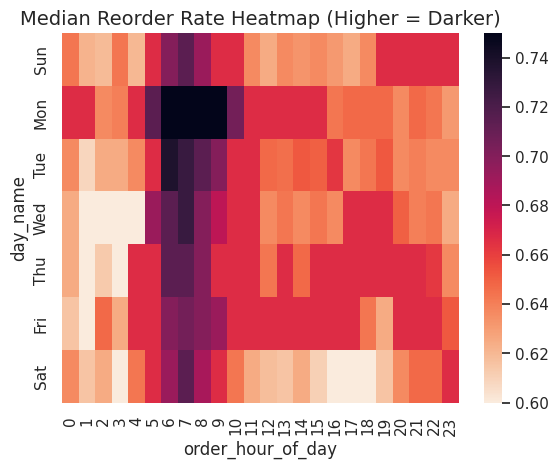

In [ ]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="median_reorder_rate"
 )

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Median Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

<Axes: xlabel='order_hour_of_day', ylabel='median_reorder_rate'>

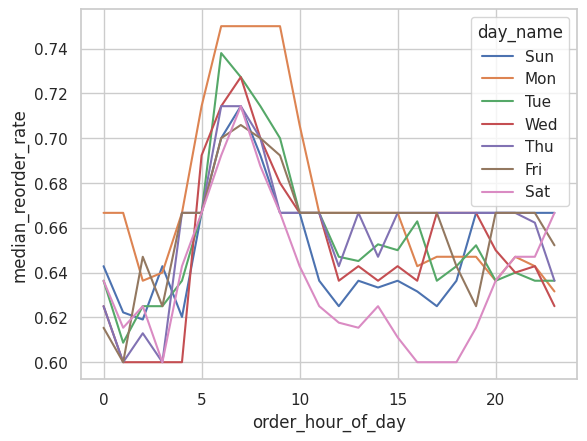

In [ ]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="median_reorder_rate",
    hue="day_name"
    )

<Axes: xlabel='day_name', ylabel='reorder_rate'>

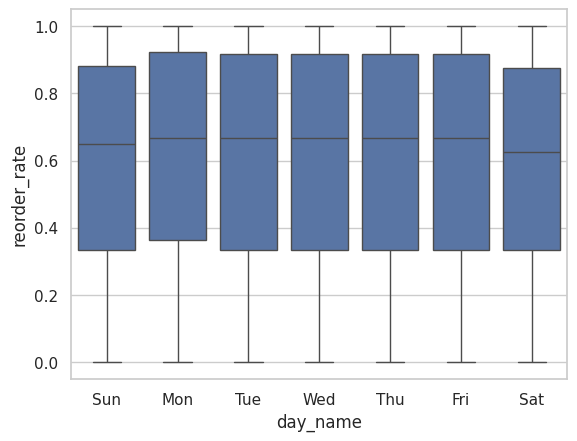

In [ ]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

## 3) Segmentation & Customer Value Lens

### 3.1 Customer Segmentation (User-level features)

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

#### 3.2 Segment Distribution Check

In [ ]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

print(f"Whale threshold (Top 10% total_orders): {whale_threshold:,.2f}")
show_df(rfm[["user_id", "total_orders", "avg_basket_size", "reorder_ratio", "days_since_last_order", "segment"]], title="User-level segmentation sample:")

segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_avg_basket_size=("avg_basket_size", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)

print("Segment summary:")
show_df(segment_summary)

Whale threshold (Top 10% total_orders): 37.00
User-level segmentation sample:


,user_id,total_orders,reorder_ratio,last_order_date,avg_basket_size,days_since_last_order,segment
0,1,10,0.6949,2015-07-01,5.9000,1,Regulars
1,2,14,0.4769,2015-07-01,13.9286,1,Regulars
2,3,12,0.6250,2015-07-01,7.3333,1,Regulars
3,4,5,0.0556,2015-07-01,3.6000,1,Regulars
4,5,4,0.3784,2015-07-01,9.2500,1,Regulars


Segment summary:


,segment,users,median_total_orders,median_avg_basket_size,median_reorder_ratio,median_days_since_last_order
0,Whales,20644,51.0000,9.3158,0.7260,1.0000
1,Regulars,185565,8.0000,8.8636,0.4000,1.0000
2,Churned,0,NaN,NaN,NaN,NaN


In [ ]:
# เชื่อมโยง Segment กลับไปที่ Data หลัก
df = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# ตรวจสอบว่ารวมสำเร็จไหม
show_df(df.groupby("segment").size().to_frame("rows"), title="Rows by segment:")

segment
Whales      11742653
Regulars    20691836
dtype: int64


#### 3.3 Segment KPI Snapshot

#### 3.4 Segment Size & Balance

In [ ]:
show_df(
    df.groupby("segment", observed=False)["order_hour_of_day"].mean().to_frame("avg_order_hour"),
    title="Average order hour by segment:",
)

segment
Whales     13.2047
Regulars   13.5500
Name: order_hour_of_day, dtype: float64

#### 3.5 Segment Spend Sanity Check

In [ ]:
# ดูสินค้า Top 3 ของแต่ละ Segment
rows = []
for seg in segment_order:
    top_prods = (
        df[df["segment"] == seg]["product_name"]
        .value_counts()
        .head(3)
        .rename("order_lines")
        .reset_index()
        .rename(columns={"index": "product_name"})
    )
    top_prods["segment"] = seg
    rows.append(top_prods)

top3_by_segment = pd.concat(rows, ignore_index=True)
show_df(top3_by_segment[["segment", "product_name", "order_lines"]], title="Top 3 products by segment:")

--- Top Products for Whales ---
product_name
Banana                    177706
Bag of Organic Bananas    163218
Organic Strawberries      117817
Name: count, dtype: int64


--- Top Products for Regulars ---
product_name
Banana                    294859
Bag of Organic Bananas    216232
Organic Baby Spinach      151371
Name: count, dtype: int64


--- Top Products for Churned ---
Series([], Name: count, dtype: int64)




#### 3.6 Segment Product Breadth

<Axes: xlabel='order_dow', ylabel='segment'>

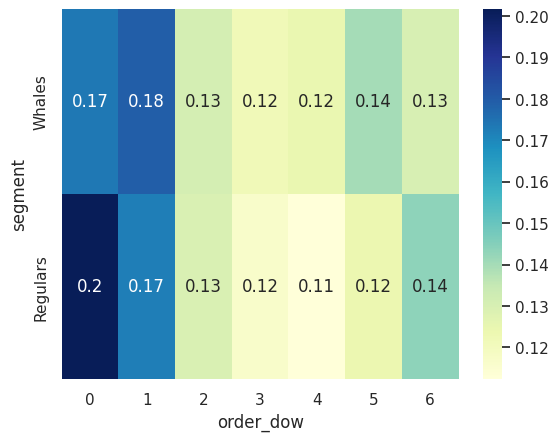

In [ ]:
# กลุ่มไหนสั่งวันเสาร์-อาทิตย์ เยอะกว่ากัน?
day_dist = pd.crosstab(df['segment'], df['order_dow'], normalize='index')
# แสดงผลเป็น Heatmap จะดูง่ายมาก
import seaborn as sns
sns.heatmap(day_dist, annot=True, cmap="YlGnBu")

### 3.7 Product Preferences by Segment
ใช้ transaction-level data ที่ join กับ segment จากตาราง user-level เพื่ออ่านพฤติกรรมสินค้าอย่างถูกบริบท

ตีความเชิงธุรกิจจากความชอบสินค้าแต่ละ segment

- Whales: สินค้า/หมวดหมู่ที่สั่งบ่อยและมีสัดส่วนสูง
- Regulars: สินค้าฐานกว้างที่สร้าง volume
- Churned: หมวดหมู่ที่อาจใช้ทำ win-back campaign

Use case:
- Recommendation
- Merchandising
- Segment-specific Marketing

#### 3.8 Segment Preference Charts

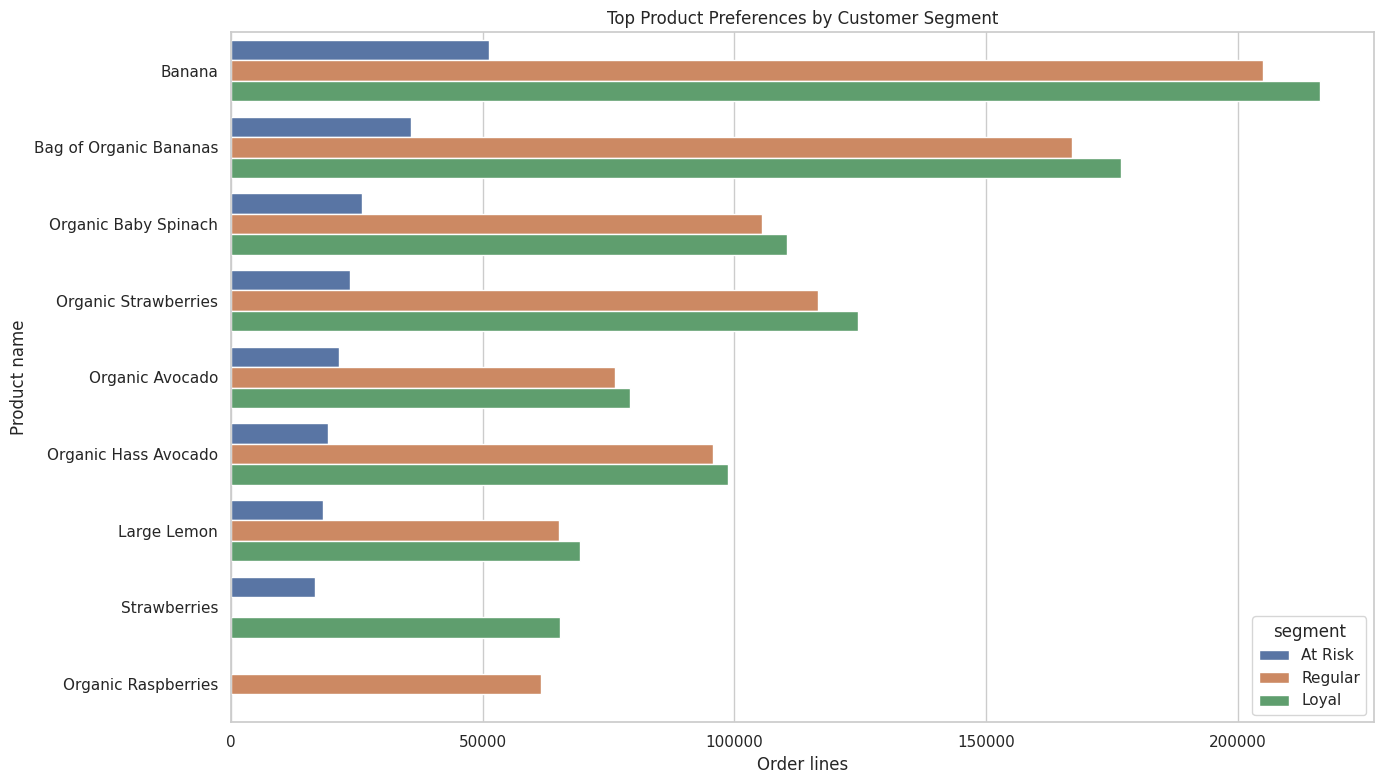

,segment,product_name,order_lines
0,At Risk,Banana,51216
1,At Risk,Bag of Organic Bananas,35675
2,At Risk,Organic Baby Spinach,25953
3,At Risk,Organic Strawberries,23552
4,At Risk,Organic Avocado,21488
5,At Risk,Organic Hass Avocado,19163
6,At Risk,Large Lemon,18227
7,At Risk,Strawberries,16588
8,Regular,Banana,205076
9,Regular,Bag of Organic Bananas,166981


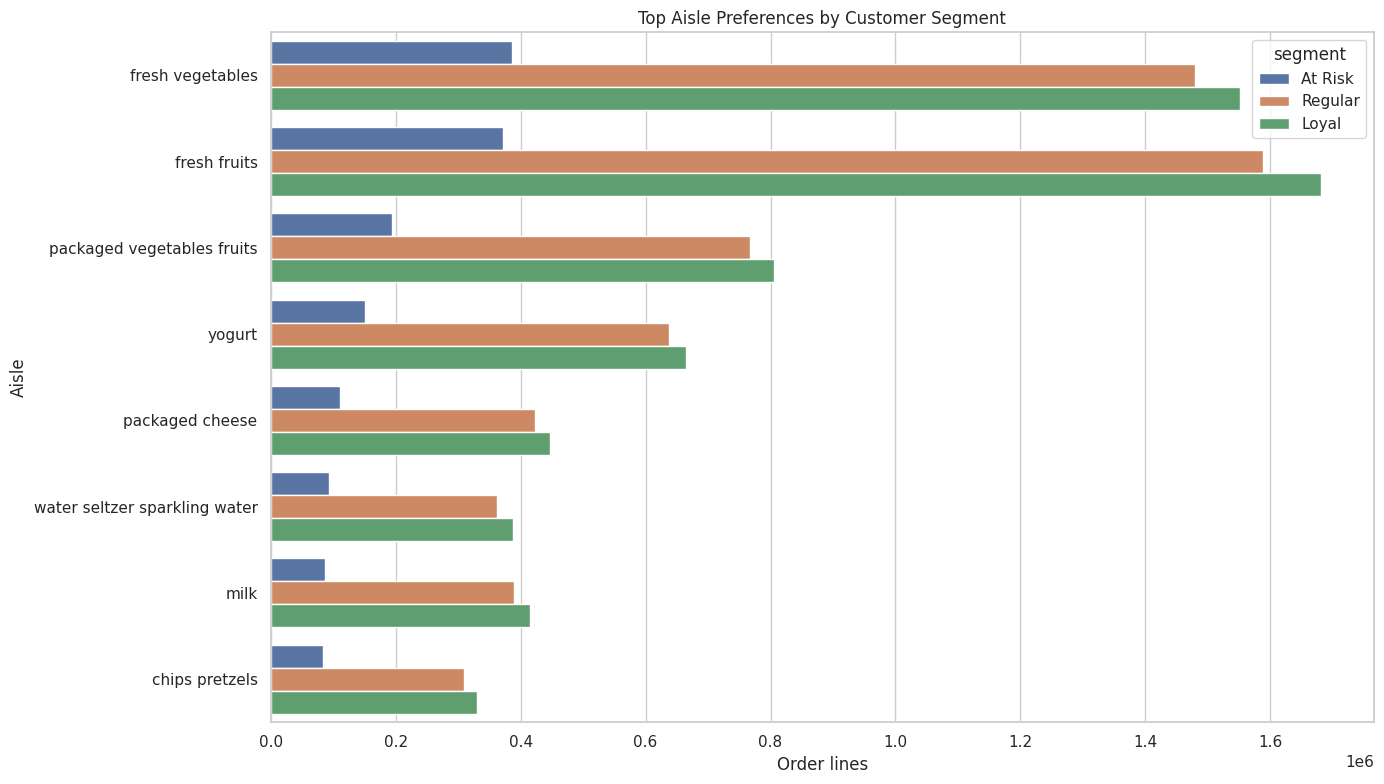

,segment,aisle,order_lines
0,At Risk,fresh vegetables,385572
1,At Risk,fresh fruits,371351
2,At Risk,packaged vegetables fruits,193286
3,At Risk,yogurt,150578
4,At Risk,packaged cheese,110285
5,At Risk,water seltzer sparkling water,92853
6,At Risk,milk,86113
7,At Risk,chips pretzels,83017
8,Regular,fresh fruits,1588953
9,Regular,fresh vegetables,1480183


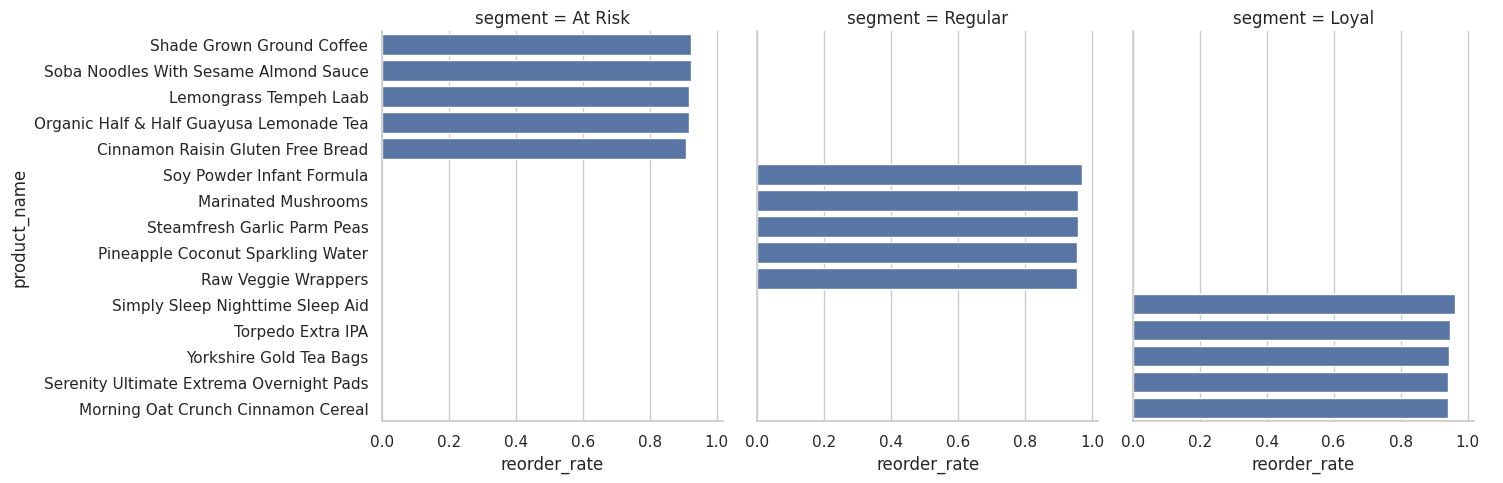

         count   mean    std    min    25%    50%    75%    max
segment                                                        
At Risk 5.0000 0.9177 0.0058 0.9091 0.9167 0.9167 0.9231 0.9231
Regular 5.0000 0.9587 0.0062 0.9552 0.9556 0.9565 0.9565 0.9697
Loyal   5.0000 0.9478 0.0088 0.9412 0.9429 0.9444 0.9474 0.9630


In [ ]:
segment_txn = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# Ensure aisle exists for aisle-level preference analysis.
if "aisle" not in segment_txn.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "aisle"]]
    segment_txn = segment_txn.merge(product_dim, on="product_id", how="left")

segment_product_pref = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.groupby(["segment", "product_name"])
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_by_segment = (
    top_reordered_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment")
    .head(5)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

show_df(top_products_by_segment, title="Top products by segment:")

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

show_df(top_aisle_by_segment, title="Top aisles by segment:")

sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1,
)
plt.show()

# Keep summary concise in clean mode.
if SHOW_VERBOSE_TABLES:
    print(top_reordered_by_segment.groupby("segment")["reorder_rate"].describe())
else:
    print("Median reorder_rate by segment:")
    display(top_reordered_by_segment.groupby("segment", observed=False)["reorder_rate"].median().to_frame("median_reorder_rate"))

## 4) Retention & Churn

Retention = ลูกค้ายัง active และกลับมาซื้อซ้ำในช่วงเวลาถัดไป
Churn = ลูกค้าไม่กลับมาซื้อภายในหน้าต่างเวลาที่กำหนด (inactivity threshold)

Framework ที่แนะนำ (ใช้ order_date):
1. สร้างเดือนของคำสั่งซื้อ: order_month
2. หา first_month ต่อ user เป็น cohort month
3. นับจำนวน user ที่ active ในแต่ละ month_index (0, 1, 2, ...)
4. คำนวณ retention_rate = active_users / cohort_size
5. กำหนด churn แบบธุรกิจ: เช่น ไม่สั่งซื้อเกิน 30 วัน = churn

หมายเหตุ: ใน Instacart ช่วงเวลาข้อมูลค่อนข้างสั้น การตั้ง threshold 30 วันมักเข้าใจง่ายและตีความได้ดี

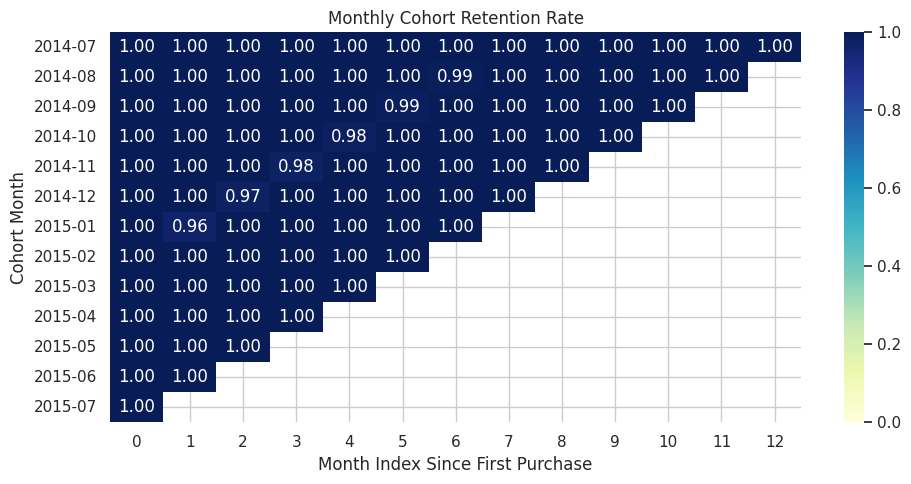

,cohort_month,month_index,active_users,cohort_size,retention_rate
0,2014-07,0,16749,16749,1.0000
1,2014-07,1,16749,16749,1.0000
2,2014-07,2,16749,16749,1.0000
3,2014-07,3,16749,16749,1.0000
4,2014-07,4,16749,16749,1.0000
5,2014-07,5,16749,16749,1.0000
6,2014-07,6,16749,16749,1.0000
7,2014-07,7,16706,16749,0.9974
8,2014-07,8,16749,16749,1.0000
9,2014-07,9,16749,16749,1.0000


,segment,customers,churn_30d_rate,median_days_since_last_order
0,At Risk,53526,0.0000,1.0000
1,Regular,75725,0.0000,1.0000
2,Loyal,76958,0.0000,1.0000


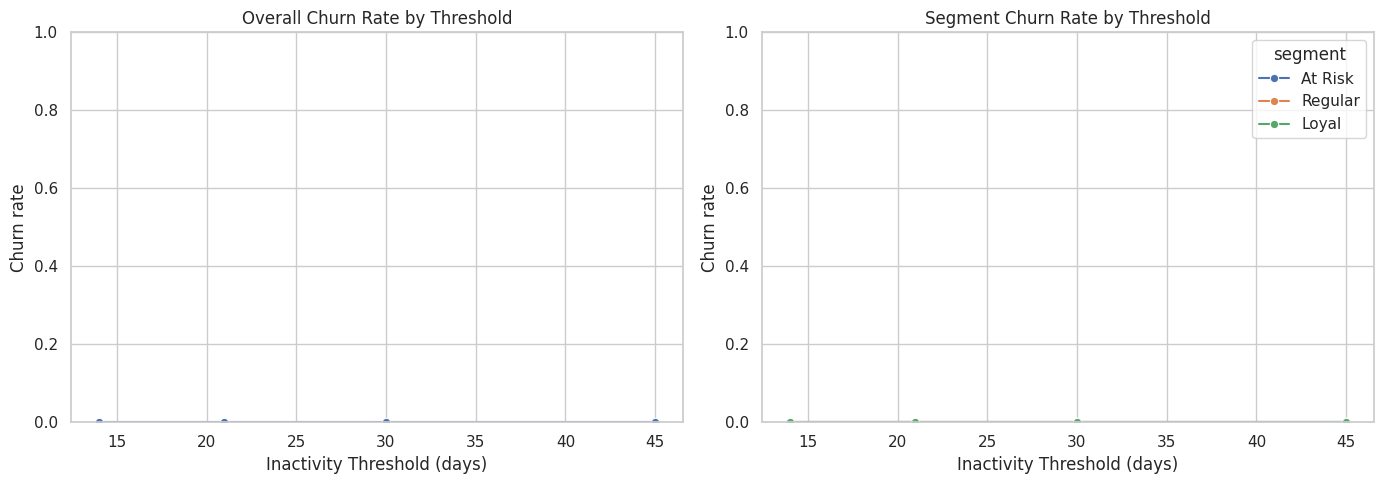

,threshold_days,churn_rate
0,14,0.0000
1,21,0.0000
2,30,0.0000
3,45,0.0000


,segment,churn_rate,threshold_days
0,At Risk,0.0000,14
3,At Risk,0.0000,21
6,At Risk,0.0000,30
9,At Risk,0.0000,45
1,Regular,0.0000,14
4,Regular,0.0000,21
7,Regular,0.0000,30
10,Regular,0.0000,45
2,Loyal,0.0000,14
5,Loyal,0.0000,21


In [ ]:
# --- Retention (Monthly Cohort) + Churn (Inactivity) using order_date ---
orders_user = (
    df[["user_id", "order_id", "order_date"]]
    .drop_duplicates()
    .copy()
)

orders_user["order_month"] = orders_user["order_date"].dt.to_period("M")
first_month = orders_user.groupby("user_id")["order_month"].min().rename("cohort_month")
orders_user = orders_user.merge(first_month, on="user_id", how="left")

orders_user["month_index"] = (
    orders_user["order_month"].astype(int) - orders_user["cohort_month"].astype(int)
)

cohort_active = (
    orders_user.groupby(["cohort_month", "month_index"], observed=False)["user_id"]
    .nunique()
    .rename("active_users")
    .reset_index()
)
cohort_size = (
    orders_user.groupby("cohort_month", observed=False)["user_id"]
    .nunique()
    .rename("cohort_size")
    .reset_index()
)
cohort_retention = cohort_active.merge(cohort_size, on="cohort_month", how="left")
cohort_retention["retention_rate"] = cohort_retention["active_users"] / cohort_retention["cohort_size"]

retention_pivot = cohort_retention.pivot(
    index="cohort_month",
    columns="month_index",
    values="retention_rate",
)

plt.figure(figsize=(10, 5))
sns.heatmap(retention_pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Monthly Cohort Retention Rate")
plt.xlabel("Month Index Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

show_df(
    cohort_retention.sort_values(["cohort_month", "month_index"]),
    title="Cohort retention sample:",
)

# Churn base table from last order date
snapshot_date = orders_user["order_date"].max() + pd.Timedelta(days=1)
last_order = orders_user.groupby("user_id")["order_date"].max().rename("last_order_date")
churn_df = last_order.to_frame().reset_index()
churn_df["days_since_last_order"] = (snapshot_date - churn_df["last_order_date"]).dt.days

# Churn at 30 days (kept for simple baseline report)
churn_df["is_churn_30d"] = churn_df["days_since_last_order"] > 30
churn_by_segment = (
    churn_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        churn_30d_rate=("is_churn_30d", "mean"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
show_df(churn_by_segment, title="Churn baseline by segment:")

# Compare multiple churn thresholds
churn_thresholds = [14, 21, 30, 45]
churn_eval = churn_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

for t in churn_thresholds:
    churn_eval[f"is_churn_{t}d"] = churn_eval["days_since_last_order"] > t

overall_churn_curve = pd.DataFrame(
    {
        "threshold_days": churn_thresholds,
        "churn_rate": [
            churn_eval[f"is_churn_{t}d"].mean()
            for t in churn_thresholds
        ],
    }
)

segment_churn_curve = pd.concat(
    [
        churn_eval.groupby("segment", observed=False)[f"is_churn_{t}d"]
        .mean()
        .rename("churn_rate")
        .reset_index()
        .assign(threshold_days=t)
        for t in churn_thresholds
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=overall_churn_curve,
    x="threshold_days",
    y="churn_rate",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Overall Churn Rate by Threshold")
axes[0].set_xlabel("Inactivity Threshold (days)")
axes[0].set_ylabel("Churn rate")
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=segment_churn_curve,
    x="threshold_days",
    y="churn_rate",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Segment Churn Rate by Threshold")
axes[1].set_xlabel("Inactivity Threshold (days)")
axes[1].set_ylabel("Churn rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

show_df(overall_churn_curve, title="Overall churn curve:")
show_df(segment_churn_curve.sort_values(["segment", "threshold_days"]), title="Segment churn curve sample:")

## 5) Basket Value & Repeat Rate by Category

Category summary (department) - top 12 by order lines:


,department,order_lines,unique_orders,unique_users,repeat_rate,avg_line_value,median_line_value,avg_category_basket_value,median_category_basket_value,p90_category_basket_value
0,produce,9479291,2409320,193237,0.6499,1.0000,1.0000,3.9344,3.0000,8.0000
1,dairy eggs,5414016,2177338,190565,0.6700,1.0000,1.0000,2.4865,2.0000,5.0000
2,snacks,2887550,1391447,174219,0.5742,1.0000,1.0000,2.0752,1.0000,4.0000
3,beverages,2690129,1457351,172795,0.6535,1.0000,1.0000,1.8459,1.0000,3.0000
4,frozen,2236432,1181018,163233,0.5419,1.0000,1.0000,1.8936,1.0000,4.0000
5,pantry,1875577,1117892,172755,0.3467,1.0000,1.0000,1.6778,1.0000,3.0000
6,bakery,1176787,881556,140612,0.6281,1.0000,1.0000,1.3349,1.0000,2.0000
7,canned goods,1068058,681305,133733,0.4574,1.0000,1.0000,1.5677,1.0000,3.0000
8,deli,1051249,770300,133865,0.6077,1.0000,1.0000,1.3647,1.0000,2.0000
9,dry goods pasta,866627,597862,124820,0.4611,1.0000,1.0000,1.4495,1.0000,2.0000


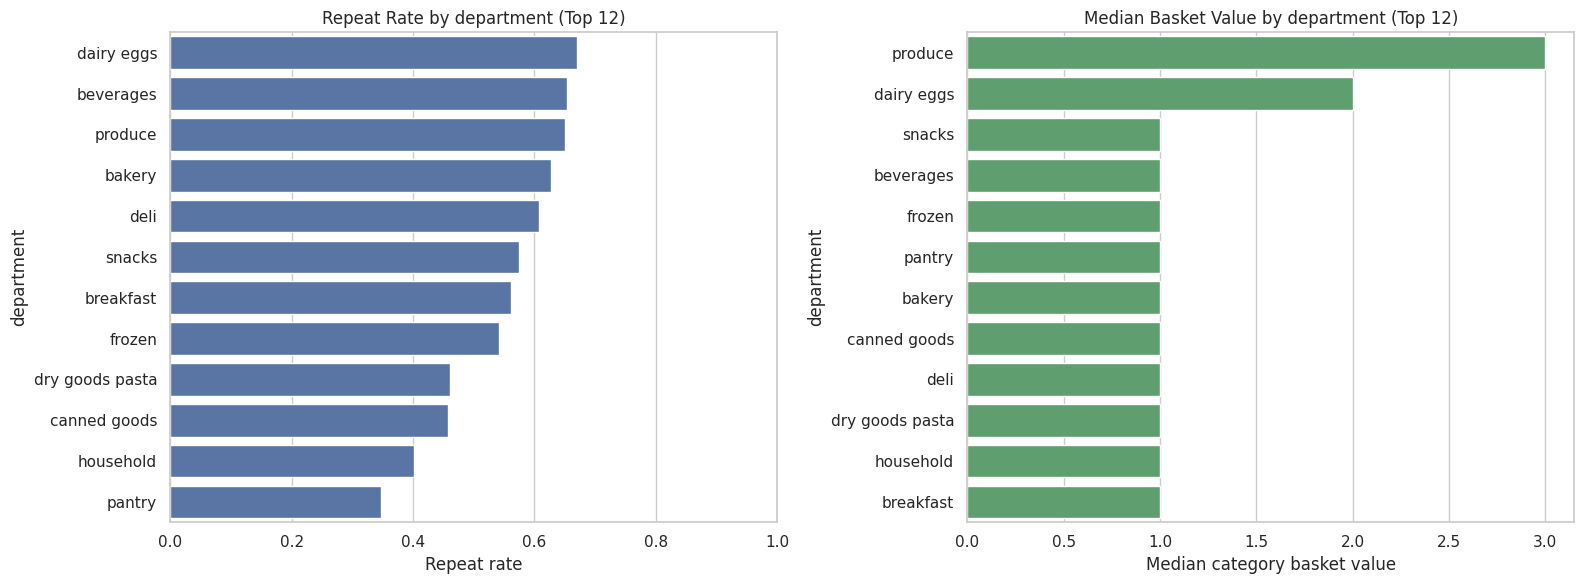

,department,order_lines,repeat_rate,avg_line_value,median_line_value,avg_category_basket_value,median_category_basket_value,p90_category_basket_value
count,21,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000
unique,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,produce,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,"1,544,499.4762",0.5211,1.0000,1.0000,1.6891,1.1429,2.9524
std,NaN,"2,231,519.2502",0.1098,0.0000,0.0000,0.6515,0.4781,1.5961
min,NaN,"34,573.0000",0.3211,1.0000,1.0000,1.0228,1.0000,1.0000
25%,NaN,"269,253.0000",0.4080,1.0000,1.0000,1.3349,1.0000,2.0000
50%,NaN,"738,666.0000",0.5677,1.0000,1.0000,1.5677,1.0000,3.0000
75%,NaN,"1,875,577.0000",0.6013,1.0000,1.0000,1.8459,1.0000,3.0000


In [ ]:
# --- Basket value / Repeat rate by product category ---
CATEGORY_COL = "department"  # switch to "aisle" for finer granularity
TOP_N_CATEGORY = 12

category_df = df.copy()

# Ensure category column exists.
if CATEGORY_COL not in category_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", CATEGORY_COL]]
    category_df = category_df.merge(product_dim, on="product_id", how="left")

category_df[CATEGORY_COL] = category_df[CATEGORY_COL].fillna("Unknown")

# 1) Line-level metrics: repeat behavior + value per line by category
category_line_metrics = (
    category_df.groupby(CATEGORY_COL, observed=False)
    .agg(
        order_lines=("product_id", "count"),
        unique_orders=("order_id", "nunique"),
        unique_users=("user_id", "nunique"),
        repeat_rate=("reordered", "mean"),
        avg_line_value=("total_price", "mean"),
        median_line_value=("total_price", "median"),
    )
    .reset_index()
    .sort_values(["order_lines", CATEGORY_COL], ascending=[False, True])
)

# 2) Order-category basket metrics: spend per order within each category
order_category_value = (
    category_df.groupby(["order_id", CATEGORY_COL], observed=False)
    .agg(category_basket_value=("total_price", "sum"))
    .reset_index()
)

category_basket_metrics = (
    order_category_value.groupby(CATEGORY_COL, observed=False)
    .agg(
        avg_category_basket_value=("category_basket_value", "mean"),
        median_category_basket_value=("category_basket_value", "median"),
        p90_category_basket_value=("category_basket_value", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

category_summary = (
    category_line_metrics.merge(category_basket_metrics, on=CATEGORY_COL, how="left")
    .sort_values(["order_lines", CATEGORY_COL], ascending=[False, True])
    .reset_index(drop=True)
)

top_categories = category_summary.head(TOP_N_CATEGORY).copy()

show_df(top_categories, title=f"Category summary ({CATEGORY_COL}) - top {TOP_N_CATEGORY} by order lines:")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_categories.sort_values("repeat_rate", ascending=False),
    x="repeat_rate",
    y=CATEGORY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Repeat Rate by {CATEGORY_COL} (Top {TOP_N_CATEGORY})")
axes[0].set_xlabel("Repeat rate")
axes[0].set_ylabel(CATEGORY_COL)
axes[0].set_xlim(0, 1)

sns.barplot(
    data=top_categories.sort_values("median_category_basket_value", ascending=False),
    x="median_category_basket_value",
    y=CATEGORY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Median Basket Value by {CATEGORY_COL} (Top {TOP_N_CATEGORY})")
axes[1].set_xlabel("Median category basket value")
axes[1].set_ylabel(CATEGORY_COL)

plt.tight_layout()
plt.show()

if SHOW_VERBOSE_TABLES:
    show_df(
        category_summary[[
            CATEGORY_COL,
            "order_lines",
            "repeat_rate",
            "avg_line_value",
            "median_line_value",
            "avg_category_basket_value",
            "median_category_basket_value",
            "p90_category_basket_value",
        ]].describe(include="all"),
        title="Category metrics describe:",
    )

## 6) Customer Lifetime Value (CLV)

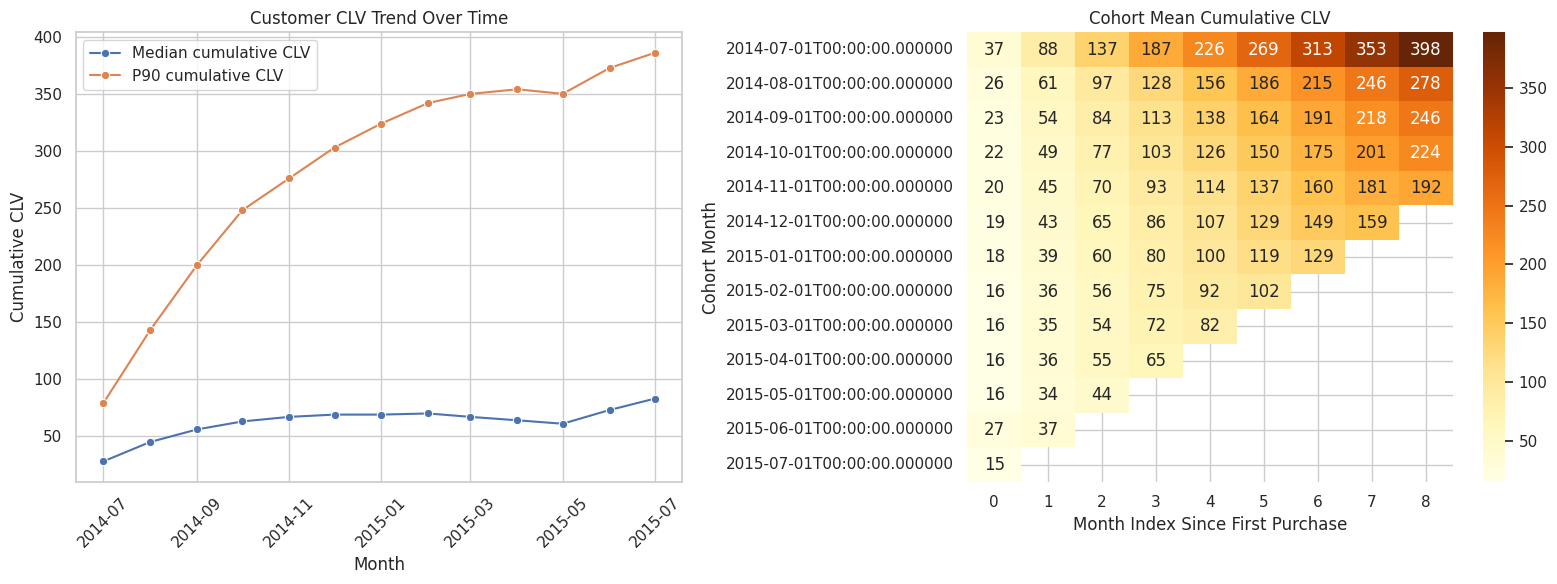

Customer CLV profile summary:


,total_orders,total_spend,avg_order_value,lifetime_days,orders_per_month,estimated_monthly_clv
count,"206,209.0000","206,209.0000","206,209.0000","206,209.0000","206,209.0000","206,209.0000"
mean,15.5904,157.2894,9.9516,157.2226,2.8264,27.9757
std,16.6548,204.2082,5.8636,103.1873,1.7122,23.8029
min,3.0000,3.0000,1.0000,1.0000,1.1111,1.1489
25%,5.0000,39.0000,5.7407,67.0000,1.7500,12.8571
50%,9.0000,83.0000,8.9333,133.0000,2.3571,21.9231
75%,19.0000,188.0000,13.0000,238.0000,3.3129,35.9140
max,99.0000,"3,725.0000",70.2500,366.0000,99.0000,"1,369.2857"


Latest CLV trend snapshot:


,order_month,active_customers,avg_monthly_spend,median_cumulative_clv,p90_cumulative_clv
7,2015-02-01,106829,24.6134,70.0000,342.0000
8,2015-03-01,130879,25.2009,67.0000,350.0000
9,2015-04-01,158541,23.8830,64.0000,354.0000
10,2015-05-01,193555,22.9522,61.0000,350.0000
11,2015-06-01,206185,22.2023,73.0000,372.6000
12,2015-07-01,206209,10.1826,83.0000,386.0000


Cohort CLV progression sample:


,cohort_month,month_index,customers,mean_cumulative_clv,median_cumulative_clv
0,2014-07-01,0,16749,36.5649,28.0000
1,2014-07-01,1,16749,87.5066,73.0000
2,2014-07-01,2,16749,137.3857,117.0000
3,2014-07-01,3,16749,187.2931,162.0000
4,2014-07-01,4,16749,225.7095,196.0000
5,2014-07-01,5,16749,268.6679,233.0000
6,2014-07-01,6,16749,312.6091,272.0000
7,2014-07-01,7,16706,353.3157,307.5000
8,2014-07-01,8,16749,397.7085,347.0000
9,2014-08-01,0,10888,26.4673,19.0000


In [ ]:
# --- Customer Lifetime Value (CLV) trends ---
CLV_FREQ = "M"  # monthly trend
MAX_MONTH_INDEX = 8  # keep cohort chart readable

if "total_price" not in df.columns:
    raise ValueError("`total_price` column is required for CLV analysis.")

# Build order-level value first to avoid line-level double counting in CLV.
order_value = (
    df.groupby(["user_id", "order_id", "order_date"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 1) Customer-level CLV profile
customer_clv = (
    order_value.groupby("user_id", observed=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        total_orders=("order_id", "nunique"),
        total_spend=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
    )
    .reset_index()
)

customer_clv["lifetime_days"] = (
    customer_clv["last_order_date"] - customer_clv["first_order_date"]
).dt.days + 1
customer_clv["lifetime_months"] = np.maximum(customer_clv["lifetime_days"] / 30.0, 1)
customer_clv["orders_per_month"] = customer_clv["total_orders"] / customer_clv["lifetime_months"]
customer_clv["estimated_monthly_clv"] = customer_clv["avg_order_value"] * customer_clv["orders_per_month"]

# 2) Monthly trend of cumulative CLV per customer
customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

clv_trend = (
    customer_monthly.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        avg_monthly_spend=("monthly_spend", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
        p90_cumulative_clv=("cumulative_clv", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

# 3) Cohort CLV progression (by first purchase month)
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")
cohort_base["month_index"] = (
    cohort_base["order_month"].dt.to_period(CLV_FREQ).astype(int)
    - cohort_base["cohort_month"].dt.to_period(CLV_FREQ).astype(int)
)

cohort_clv = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
)

cohort_clv_progress = (
    cohort_clv[cohort_clv["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index"], observed=False)
    .agg(
        customers=("user_id", "nunique"),
        mean_cumulative_clv=("cumulative_clv", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
)

cohort_clv_pivot = cohort_clv_progress.pivot(
    index="cohort_month",
    columns="month_index",
    values="mean_cumulative_clv",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    marker="o",
    label="Median cumulative CLV",
    ax=axes[0],
)
sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="p90_cumulative_clv",
    marker="o",
    label="P90 cumulative CLV",
    ax=axes[0],
)
axes[0].set_title("Customer CLV Trend Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cohort_clv_pivot, annot=True, fmt=".0f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Cohort Mean Cumulative CLV")
axes[1].set_xlabel("Month Index Since First Purchase")
axes[1].set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

show_df(
    customer_clv[[
        "total_orders",
        "total_spend",
        "avg_order_value",
        "lifetime_days",
        "orders_per_month",
        "estimated_monthly_clv",
    ]].describe(),
    title="Customer CLV profile summary:",
)
show_df(clv_trend.tail(6), title="Latest CLV trend snapshot:")

if SHOW_VERBOSE_TABLES:
    show_df(cohort_clv_progress.head(20), title="Cohort CLV progression sample:")

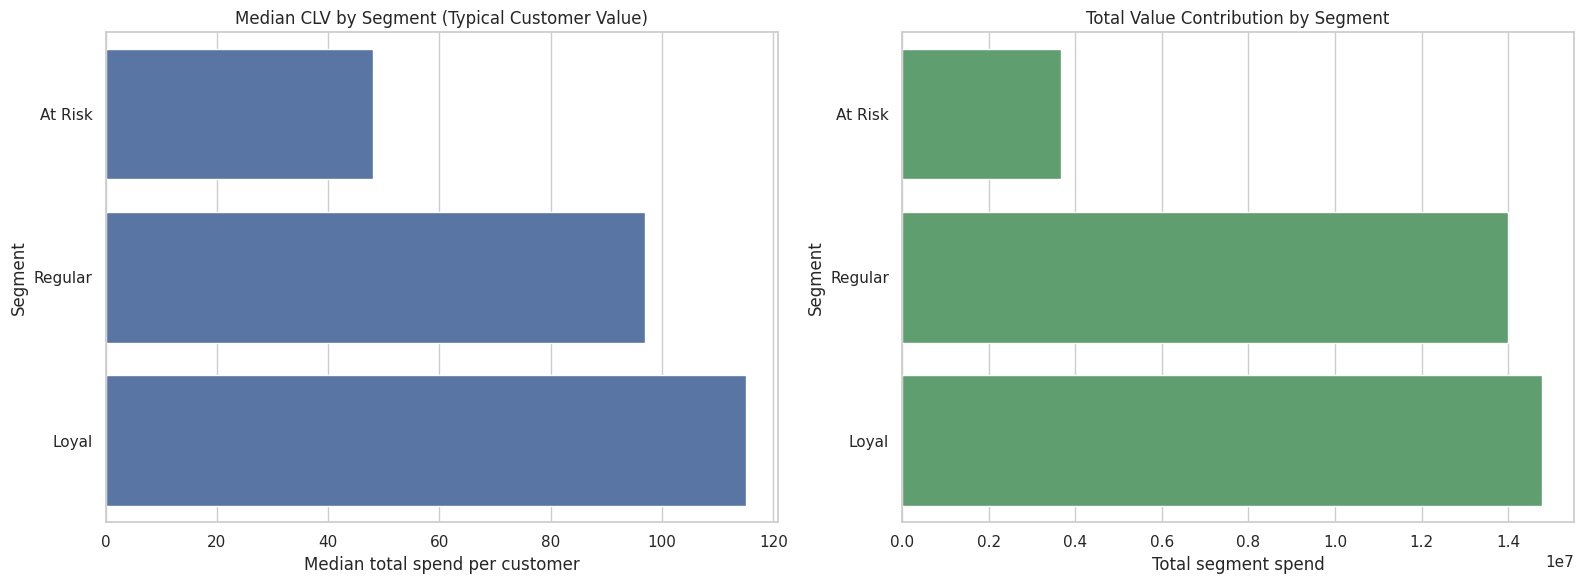

Segment CLV summary (median-focused + business contribution):


,segment,customers,median_total_spend,mean_total_spend,median_avg_order_value,median_orders_per_month,median_estimated_monthly_clv,total_segment_spend,segment_share_of_spend,median_latest_cumulative_clv
0,Loyal,76958,115.0000,192.0589,9.0000,2.5000,23.4113,14780466,0.4557,115.0000
1,Regular,75725,97.0000,184.7205,9.0000,2.4812,23.0435,13987957,0.4313,97.0000
2,At Risk,53526,48.0000,68.4913,8.7059,2.0455,18.6486,3666066,0.1130,48.0000


Top segment by median customer value: Loyal (median_total_spend=115.00)
Top segment by total business contribution: Loyal (total_segment_spend=14,780,466.00, share=45.57%)


In [ ]:
# --- CLV by segment (median-focused) ---
# Why median: robust to extreme spenders and better reflects a "typical" customer in each segment.

if "segment" not in rfm.columns:
    raise ValueError("`rfm` with `segment` column is required for segment-level CLV analysis.")

# Join customer CLV profile with existing RFM segment labels.
segment_clv_base = customer_clv.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_clv_base["segment"] = segment_clv_base["segment"].fillna("Unknown")

segment_clv_summary = (
    segment_clv_base.groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        median_total_spend=("total_spend", "median"),
        mean_total_spend=("total_spend", "mean"),
        median_avg_order_value=("avg_order_value", "median"),
        median_orders_per_month=("orders_per_month", "median"),
        median_estimated_monthly_clv=("estimated_monthly_clv", "median"),
        total_segment_spend=("total_spend", "sum"),
    )
    .reset_index()
)

segment_clv_summary["segment_share_of_spend"] = (
    segment_clv_summary["total_segment_spend"]
    / segment_clv_summary["total_segment_spend"].sum()
)

segment_clv_summary = segment_clv_summary.sort_values(
    ["median_total_spend", "total_segment_spend"],
    ascending=[False, False],
).reset_index(drop=True)

# Latest cumulative CLV per customer (for an alternative median view).
latest_customer_clv = (
    customer_monthly.sort_values(["user_id", "order_month"])
    .groupby("user_id", observed=False)
    .tail(1)[["user_id", "cumulative_clv"]]
)

segment_latest_median = (
    latest_customer_clv.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(median_latest_cumulative_clv=("cumulative_clv", "median"))
    .reset_index()
)

segment_clv_summary = segment_clv_summary.merge(
    segment_latest_median,
    on="segment",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=segment_clv_summary.sort_values("median_total_spend", ascending=False),
    x="median_total_spend",
    y="segment",
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("Median CLV by Segment (Typical Customer Value)")
axes[0].set_xlabel("Median total spend per customer")
axes[0].set_ylabel("Segment")

sns.barplot(
    data=segment_clv_summary.sort_values("total_segment_spend", ascending=False),
    x="total_segment_spend",
    y="segment",
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title("Total Value Contribution by Segment")
axes[1].set_xlabel("Total segment spend")
axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.show()

show_df(segment_clv_summary, title="Segment CLV summary:")

top_median_segment = segment_clv_summary.iloc[0]
top_total_segment = segment_clv_summary.sort_values("total_segment_spend", ascending=False).iloc[0]

print(
    f"Top segment by median customer value: {top_median_segment['segment']} "
    f"(median_total_spend={top_median_segment['median_total_spend']:,.2f})"
)
print(
    f"Top segment by total business contribution: {top_total_segment['segment']} "
    f"(total_segment_spend={top_total_segment['total_segment_spend']:,.2f}, "
    f"share={top_total_segment['segment_share_of_spend']:.2%})"
)

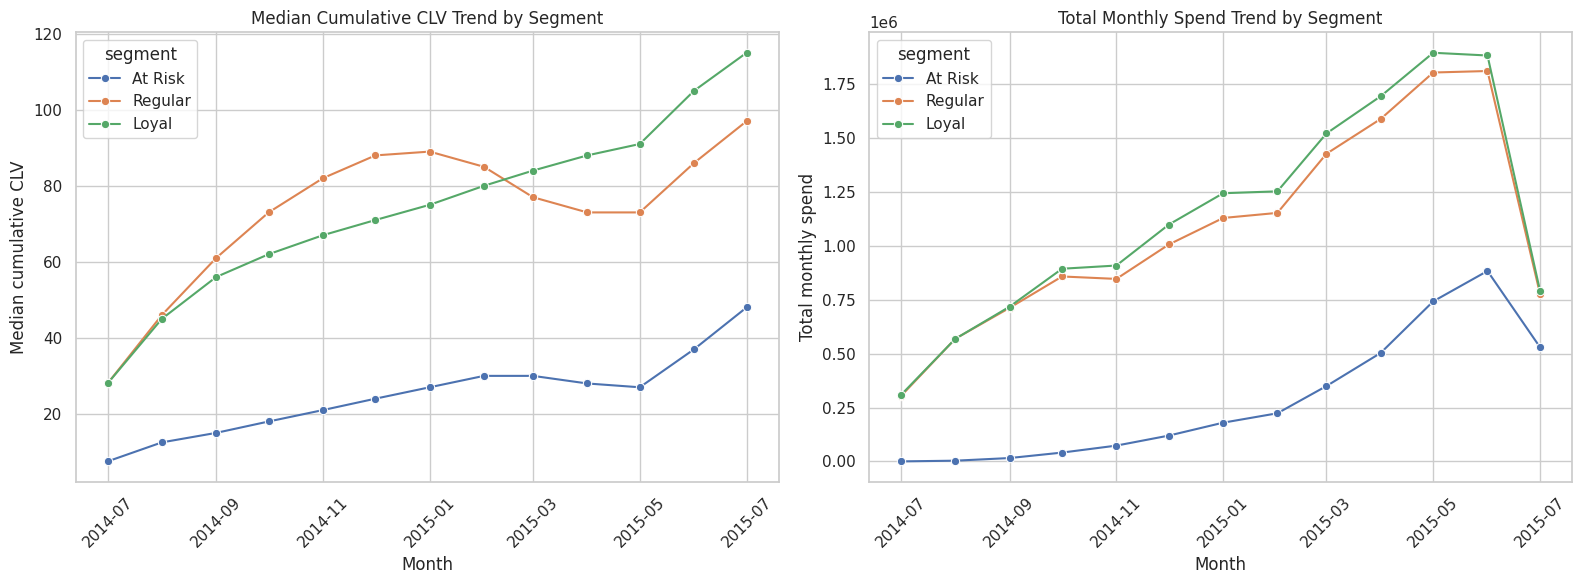

Segment CLV monthly trend snapshot:


,order_month,segment,active_customers,total_monthly_spend,median_monthly_spend,median_cumulative_clv
27,2015-04-01,At Risk,31741,503405,11.0000,28.0000
28,2015-04-01,Regular,62222,1588830,17.0000,73.0000
29,2015-04-01,Loyal,64578,1694198,18.0000,88.0000
30,2015-05-01,At Risk,47482,742530,11.0000,27.0000
31,2015-05-01,Regular,72309,1804174,16.0000,73.0000
32,2015-05-01,Loyal,73764,1895803,17.0000,91.0000
33,2015-06-01,At Risk,53515,883532,12.0000,37.0000
34,2015-06-01,Regular,75717,1811123,16.0000,86.0000
35,2015-06-01,Loyal,76953,1883120,16.0000,105.0000
36,2015-07-01,At Risk,53526,529868,8.0000,48.0000


Pairwise median CLV comparison by segment (permutation test + BH correction):


,segment_a,segment_b,n_a,n_b,median_a,median_b,median_diff_a_minus_b,p_value,q_value_bh,significant_5pct
0,At Risk,Loyal,53526,76958,48.0000,115.0000,-67.0000,0.0005,0.0005,True
1,At Risk,Regular,53526,75725,48.0000,97.0000,-49.0000,0.0005,0.0005,True
2,Loyal,Regular,76958,75725,115.0000,97.0000,18.0000,0.0005,0.0005,True


In [ ]:
# --- Segment CLV trend over time + median significance checks ---
SEGMENT_CLV_TEST_PERMUTATIONS = 2000
RANDOM_SEED = 42

segment_monthly = customer_monthly.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_monthly["segment"] = segment_monthly["segment"].fillna("Unknown")

segment_clv_trend = (
    segment_monthly.groupby(["order_month", "segment"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_monthly_spend=("monthly_spend", "sum"),
        median_monthly_spend=("monthly_spend", "median"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
    .sort_values(["order_month", "segment"])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    hue="segment",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Median Cumulative CLV Trend by Segment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="total_monthly_spend",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Total Monthly Spend Trend by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total monthly spend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(segment_clv_trend.tail(12), title="Segment CLV monthly trend snapshot:")


def permutation_test_median_diff(a, b, n_permutations=2000, seed=42):
    """Two-sided permutation test for median difference."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan

    observed = np.median(a) - np.median(b)
    combined = np.concatenate([a, b])
    n_a = len(a)

    rng = np.random.default_rng(seed)
    extreme = 0
    for _ in range(n_permutations):
        permuted = rng.permutation(combined)
        diff = np.median(permuted[:n_a]) - np.median(permuted[n_a:])
        if abs(diff) >= abs(observed):
            extreme += 1

    p_value = (extreme + 1) / (n_permutations + 1)
    return observed, p_value


def benjamini_hochberg(p_values):
    """Return BH-adjusted q-values in original order."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked_p[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    q = np.clip(q, 0, 1)
    q_original_order = np.empty(n, dtype=float)
    q_original_order[order] = q
    return q_original_order


segment_spend_for_test = segment_clv_base[["segment", "total_spend"]].dropna().copy()
segments = sorted(segment_spend_for_test["segment"].unique())

pairwise_results = []
for i in range(len(segments)):
    for j in range(i + 1, len(segments)):
        seg_a = segments[i]
        seg_b = segments[j]

        spend_a = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_a,
            "total_spend",
        ]
        spend_b = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_b,
            "total_spend",
        ]

        median_diff, p_value = permutation_test_median_diff(
            spend_a,
            spend_b,
            n_permutations=SEGMENT_CLV_TEST_PERMUTATIONS,
            seed=RANDOM_SEED,
        )

        pairwise_results.append(
            {
                "segment_a": seg_a,
                "segment_b": seg_b,
                "n_a": int(spend_a.shape[0]),
                "n_b": int(spend_b.shape[0]),
                "median_a": float(np.median(spend_a)),
                "median_b": float(np.median(spend_b)),
                "median_diff_a_minus_b": float(median_diff),
                "p_value": float(p_value),
            }
        )

pairwise_median_test = pd.DataFrame(pairwise_results).sort_values("p_value").reset_index(drop=True)
pairwise_median_test["q_value_bh"] = benjamini_hochberg(pairwise_median_test["p_value"].values)
pairwise_median_test["significant_5pct"] = pairwise_median_test["q_value_bh"] < 0.05

show_df(pairwise_median_test, title="Pairwise median CLV comparison:")

### 6.1 Days Between Orders Distribution by Segment

วิเคราะห์ cadence ของแต่ละ segment ด้วย `days_since_prior_order` แบบ customer-median เพื่อลด noise จาก order รายครั้ง

- Distribution plot: เปรียบเทียบ density ในภาพเดียว
- Box plot: ดู median / IQR / spread ต่อกลุ่ม
- Summary table: customers, median, mean, std, p25, p75

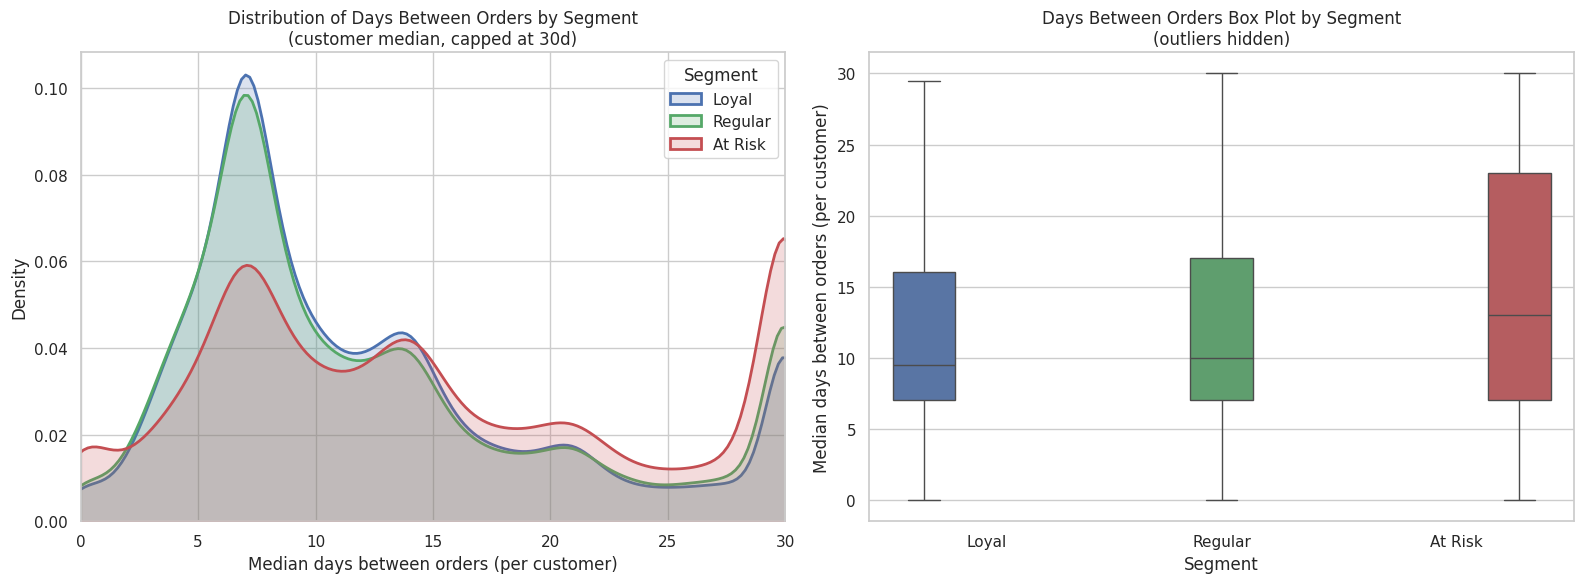

Days between orders summary by segment (customer-level median):


,segment,customers,median,mean,std,p25,p75
0,Loyal,76958,9.5000,12.1722,7.8784,7.0000,16.0000
1,Regular,75725,10.0000,12.5719,8.3414,7.0000,17.0000
2,At Risk,53526,13.0000,15.1155,9.3711,7.0000,23.0000



กลุ่มที่สั่งซื้อถี่ที่สุด: Loyal (median = 9.5 วัน, IQR = 7.0–16.0)


In [ ]:
# --- Days between orders distribution per segment ---
# Use customer-level median to represent each customer's "typical" gap.
# This avoids noise from the first order (NaN days) and large purchase streaks.

days_df = (
    df[df["days_since_prior_order"].notna()]
    .groupby("user_id", observed=False)
    .agg(customer_median_days=("days_since_prior_order", "median"))
    .reset_index()
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
days_df["segment"] = days_df["segment"].fillna("Unknown")

DAYS_CAP = 30  # cap at 30 for readability; 30d = monthly cadence max
days_plot = days_df.copy()
days_plot["customer_median_days"] = days_plot["customer_median_days"].clip(upper=DAYS_CAP)

SEGMENT_ORDER = ["Whales", "Regulars", "Churned"]
PALETTE = {"Whales": "#4C72B0", "Regulars": "#55A868", "Churned": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE distribution via seaborn (no scipy needed)
for seg in SEGMENT_ORDER:
    grp = days_plot[days_plot["segment"] == seg]["customer_median_days"]
    if len(grp) > 1:
        sns.kdeplot(grp, ax=axes[0], label=seg, linewidth=2, color=PALETTE[seg], fill=True, alpha=0.2)

axes[0].set_title("Distribution of Days Between Orders by Segment\n(customer median, capped at 30d)")
axes[0].set_xlabel("Median days between orders (per customer)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, DAYS_CAP)
axes[0].legend(title="Segment")

# Box plot — median + spread (outliers hidden for readability)
sns.boxplot(
    data=days_df,
    x="segment",
    y="customer_median_days",
    hue="segment",
    order=SEGMENT_ORDER,
    hue_order=SEGMENT_ORDER,
    palette=PALETTE,
    ax=axes[1],
    showfliers=False,
    legend=False,
)
axes[1].set_title("Days Between Orders Box Plot by Segment\n(outliers hidden)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Median days between orders (per customer)")

plt.tight_layout()
plt.show()

# Summary table
days_summary = (
    days_df.groupby("segment", observed=False)["customer_median_days"]
    .agg(
        customers="count",
        median="median",
        mean="mean",
        std="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .reset_index()
    .sort_values("median")
    .reset_index(drop=True)
)

show_df(days_summary, title="Days between orders summary by segment:")

top_freq = days_summary.iloc[0]
print(
    f"\nกลุ่มที่สั่งซื้อถี่ที่สุด: {top_freq['segment']} "
    f"(median = {top_freq['median']:.1f} วัน, IQR = {top_freq['p25']:.1f}–{top_freq['p75']:.1f})"
)

### 6.2 Order Funnel (% Customers Reaching Each Order)

วิเคราะห์ drop-off ของลูกค้าตามจำนวน order สะสม

- Funnel bar chart: % ลูกค้าที่มีอย่างน้อย N orders
- Drop-off rate: % ที่หายไประหว่างแต่ละขั้น
- Segment funnel: เปรียบเทียบ Whales / Regulars / Churned

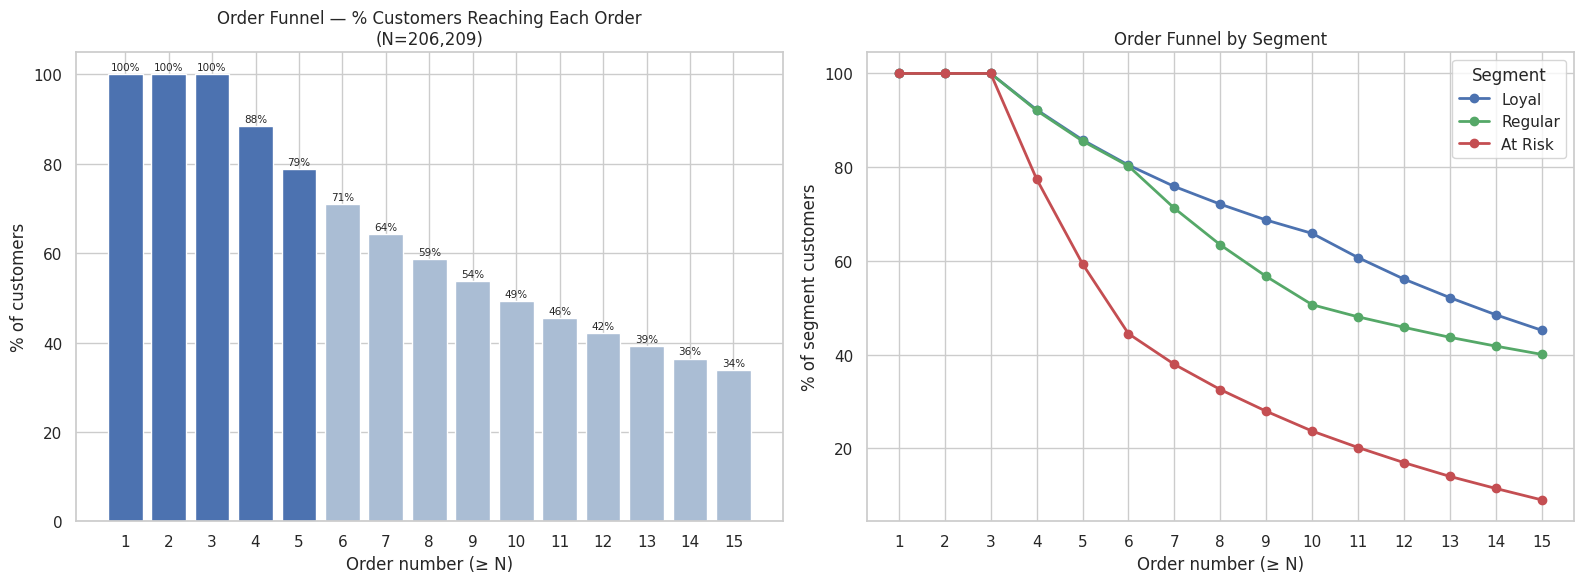

Overall funnel table:


,order_n,customers_reached,pct_of_total,drop_off_pct
0,1,206209,1.0000,0.0000
1,2,206209,1.0000,0.0000
2,3,206209,1.0000,0.1163
3,4,182223,0.8837,0.0950
4,5,162633,0.7887,0.0784
5,6,146468,0.7103,0.0672
6,7,132618,0.6431,0.0567
7,8,120918,0.5864,0.0494
8,9,110728,0.5370,0.0438
9,10,101696,0.4932,0.0379



Big drop-off points (>5% lost between consecutive steps):


,order_n,pct_of_total,drop_off_pct
2,3,1.0000,0.1163
3,4,0.8837,0.0950
4,5,0.7887,0.0784
5,6,0.7103,0.0672
6,7,0.6431,0.0567


In [ ]:
# --- Order Funnel ---
FUNNEL_MAX_ORDER = 15  # show up to order #15

# Customer max order number (total_orders per customer)
user_max_order = (
    df.groupby("user_id", observed=False)["order_number"]
    .max()
    .reset_index()
    .rename(columns={"order_number": "max_order"})
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
user_max_order["segment"] = user_max_order["segment"].fillna("Unknown")

total_customers = user_max_order["user_id"].nunique()

# Overall funnel: % of customers with max_order >= n
funnel_steps = range(1, FUNNEL_MAX_ORDER + 1)
funnel = pd.DataFrame(
    {
        "order_n": list(funnel_steps),
        "customers_reached": [
            (user_max_order["max_order"] >= n).sum() for n in funnel_steps
        ],
    }
)
funnel["pct_of_total"] = funnel["customers_reached"] / total_customers
funnel["drop_off_pct"] = funnel["pct_of_total"].diff(-1).clip(lower=0)

# Segment funnel
seg_funnel_rows = []
for seg in SEGMENT_ORDER + ["Unknown"]:
    seg_users = user_max_order[user_max_order["segment"] == seg]
    n_seg = len(seg_users)
    if n_seg == 0:
        continue
    for n in funnel_steps:
        seg_funnel_rows.append(
            {
                "segment": seg,
                "order_n": n,
                "pct_reached": (seg_users["max_order"] >= n).sum() / n_seg,
            }
        )
seg_funnel = pd.DataFrame(seg_funnel_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall funnel bar chart
bar_colors = ["#4C72B0" if n <= 5 else "#AABDD4" for n in funnel["order_n"]]
axes[0].bar(funnel["order_n"], funnel["pct_of_total"] * 100, color=bar_colors, edgecolor="white")
axes[0].set_title(f"Order Funnel — % Customers Reaching Each Order\n(N={total_customers:,})")
axes[0].set_xlabel("Order number (>= N)")
axes[0].set_ylabel("% of customers")
axes[0].set_xticks(list(funnel_steps))

# Segment funnel line chart
seg_palette = dict(zip(SEGMENT_ORDER, ["#4C72B0", "#55A868", "#C44E52"]))
for seg in SEGMENT_ORDER:
    seg_data = seg_funnel[seg_funnel["segment"] == seg]
    if not seg_data.empty:
        axes[1].plot(
            seg_data["order_n"],
            seg_data["pct_reached"] * 100,
            marker="o",
            label=seg,
            color=seg_palette.get(seg),
            linewidth=2,
        )
axes[1].set_title("Order Funnel by Segment")
axes[1].set_xlabel("Order number (>= N)")
axes[1].set_ylabel("% of segment customers")
axes[1].set_xticks(list(funnel_steps))
axes[1].legend(title="Segment")

plt.tight_layout()
plt.show()

show_df(funnel, title="Overall funnel table:")

# Key drop-off points (drop > 5%)
big_drops = funnel[funnel["drop_off_pct"] > 0.05].copy()
show_df(big_drops[["order_n", "pct_of_total", "drop_off_pct"]], title="Big drop-off points (>5%):")

### 6.3 First Purchase Category (Gateway Category)

หา "gateway category" ที่พาลูกค้าใหม่เข้าสู่การเป็น Whales

- Top departments/aisles ในออร์เดอร์แรก (`order_number = 1`)
- เปรียบเทียบตาม segment
- Conversion insight: gateway category ไหนมีสัดส่วนกลายเป็น Whales สูง

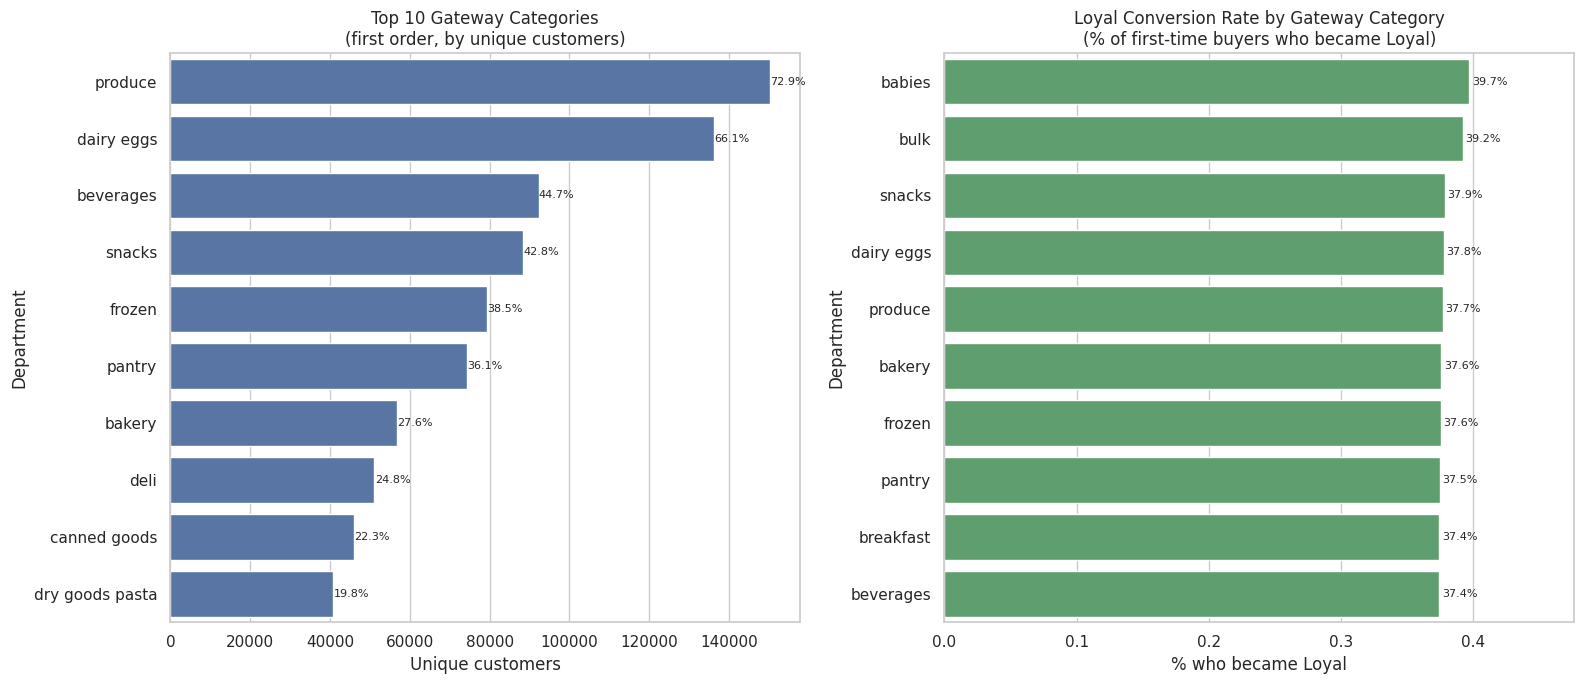

Overall top gateway categories (department):


,department,customers,order_lines,pct_of_new_customers
0,produce,150245,584384,0.7286
1,dairy eggs,136272,333030,0.6608
2,beverages,92264,167618,0.4474
3,snacks,88331,180909,0.4284
4,frozen,79311,158323,0.3846
5,pantry,74426,128268,0.3609
6,bakery,56870,75541,0.2758
7,deli,51136,70099,0.2480
8,canned goods,45911,73766,0.2226
9,dry goods pasta,40797,60982,0.1978



Top gateway categories by segment:


,segment,department,customers,pct_in_segment
0,At Risk,produce,38131,0.1513
1,At Risk,dairy eggs,34539,0.1371
2,At Risk,beverages,23622,0.0938
3,At Risk,snacks,22137,0.0879
4,At Risk,frozen,20491,0.0813
5,At Risk,pantry,19111,0.0758
6,At Risk,bakery,14477,0.0575
7,At Risk,deli,12957,0.0514
8,At Risk,canned goods,12068,0.0479
9,At Risk,dry goods pasta,10641,0.0422



Loyal conversion rate by gateway category:


,department,loyal_conversion_rate
0,babies,0.3970
1,bulk,0.3921
2,snacks,0.3786
3,dairy eggs,0.3779
4,produce,0.3772
5,bakery,0.3758
6,frozen,0.3755
7,pantry,0.3750
8,breakfast,0.3745
9,beverages,0.3744


In [ ]:
# --- First Purchase Category ---
TOP_N_GATEWAY = 10
GATEWAY_COL = "department"  # switch to "aisle" for finer granularity

first_order_df = df[df["order_number"] == 1].copy()

# Ensure department column exists
if GATEWAY_COL not in first_order_df.columns:
    product_dim_gw = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE, project_root=PROJECT_ROOT
    )[["product_id", GATEWAY_COL]]
    first_order_df = first_order_df.merge(product_dim_gw, on="product_id", how="left")

first_order_df[GATEWAY_COL] = first_order_df[GATEWAY_COL].fillna("Unknown")

# 1) Overall top gateway categories
gateway_overall = (
    first_order_df.groupby(GATEWAY_COL, observed=False)
    .agg(customers=("user_id", "nunique"), order_lines=("product_id", "count"))
    .reset_index()
    .sort_values("customers", ascending=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)
gateway_overall["pct_of_new_customers"] = (
    gateway_overall["customers"] / first_order_df["user_id"].nunique()
)

# 2) Gateway by segment — which category did each segment start with?
first_order_seg = first_order_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
first_order_seg["segment"] = first_order_seg["segment"].fillna("Unknown")

gateway_by_segment = (
    first_order_seg.groupby(["segment", GATEWAY_COL], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
seg_totals = gateway_by_segment.groupby("segment", observed=False)["customers"].transform("sum")
gateway_by_segment["pct_in_segment"] = gateway_by_segment["customers"] / seg_totals

top_gateway_by_segment = (
    gateway_by_segment.sort_values(["segment", "customers"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)

# 3) Conversion: for each gateway category, what % ended up as Whales?
whales_first = (
    first_order_seg.groupby([GATEWAY_COL, "segment"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
cat_totals = whales_first.groupby(GATEWAY_COL, observed=False)["customers"].transform("sum")
whales_first["pct_in_cat"] = whales_first["customers"] / cat_totals

whale_conversion = (
    whales_first[whales_first["segment"] == "Whales"]
    [[GATEWAY_COL, "pct_in_cat"]]
    .rename(columns={"pct_in_cat": "whale_conversion_rate"})
    .sort_values("whale_conversion_rate", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=gateway_overall,
    x="customers",
    y=GATEWAY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Top {TOP_N_GATEWAY} Gateway Categories\n(first order, by unique customers)")
axes[0].set_xlabel("Unique customers")
axes[0].set_ylabel(GATEWAY_COL.title())

# Whales conversion rate by gateway category (top 10)
top_whale_conv = whale_conversion.head(TOP_N_GATEWAY)
sns.barplot(
    data=top_whale_conv,
    x="whale_conversion_rate",
    y=GATEWAY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Whales Conversion Rate by Gateway Category\n(% of first-time buyers who became Whales)")
axes[1].set_xlabel("% who became Whales")
axes[1].set_ylabel(GATEWAY_COL.title())
axes[1].set_xlim(0, top_whale_conv["whale_conversion_rate"].max() * 1.2)

plt.tight_layout()
plt.show()

show_df(gateway_overall, title=f"Overall top gateway categories ({GATEWAY_COL}):")
show_df(top_gateway_by_segment, title="Top gateway categories by segment:")
show_df(whale_conversion, title="Whales conversion rate by gateway category:")

## 7) Trend Deep Dive (User & Product)

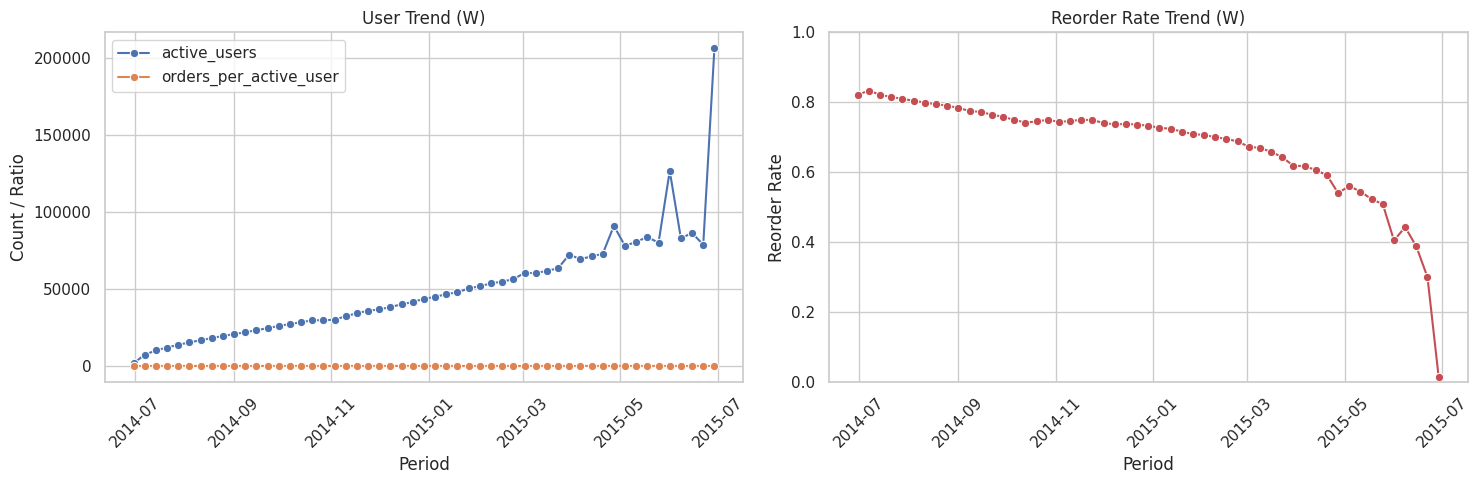

,period,active_users,orders,order_lines,reorder_rate,orders_per_active_user
0,2014-06-30,1751,2048,20541,0.8219,1.1696
1,2014-07-07,7266,9902,116219,0.8329,1.3628
2,2014-07-14,10062,13618,159468,0.8213,1.3534
3,2014-07-21,11942,16140,186121,0.8149,1.3515
4,2014-07-28,13713,18547,211681,0.8096,1.3525
5,2014-08-04,15257,20418,233989,0.8041,1.3383
6,2014-08-11,16691,22327,254191,0.7992,1.3377
7,2014-08-18,18060,24169,275798,0.7941,1.3383
8,2014-08-25,19439,25891,295816,0.7901,1.3319
9,2014-09-01,20658,27422,309658,0.7840,1.3274


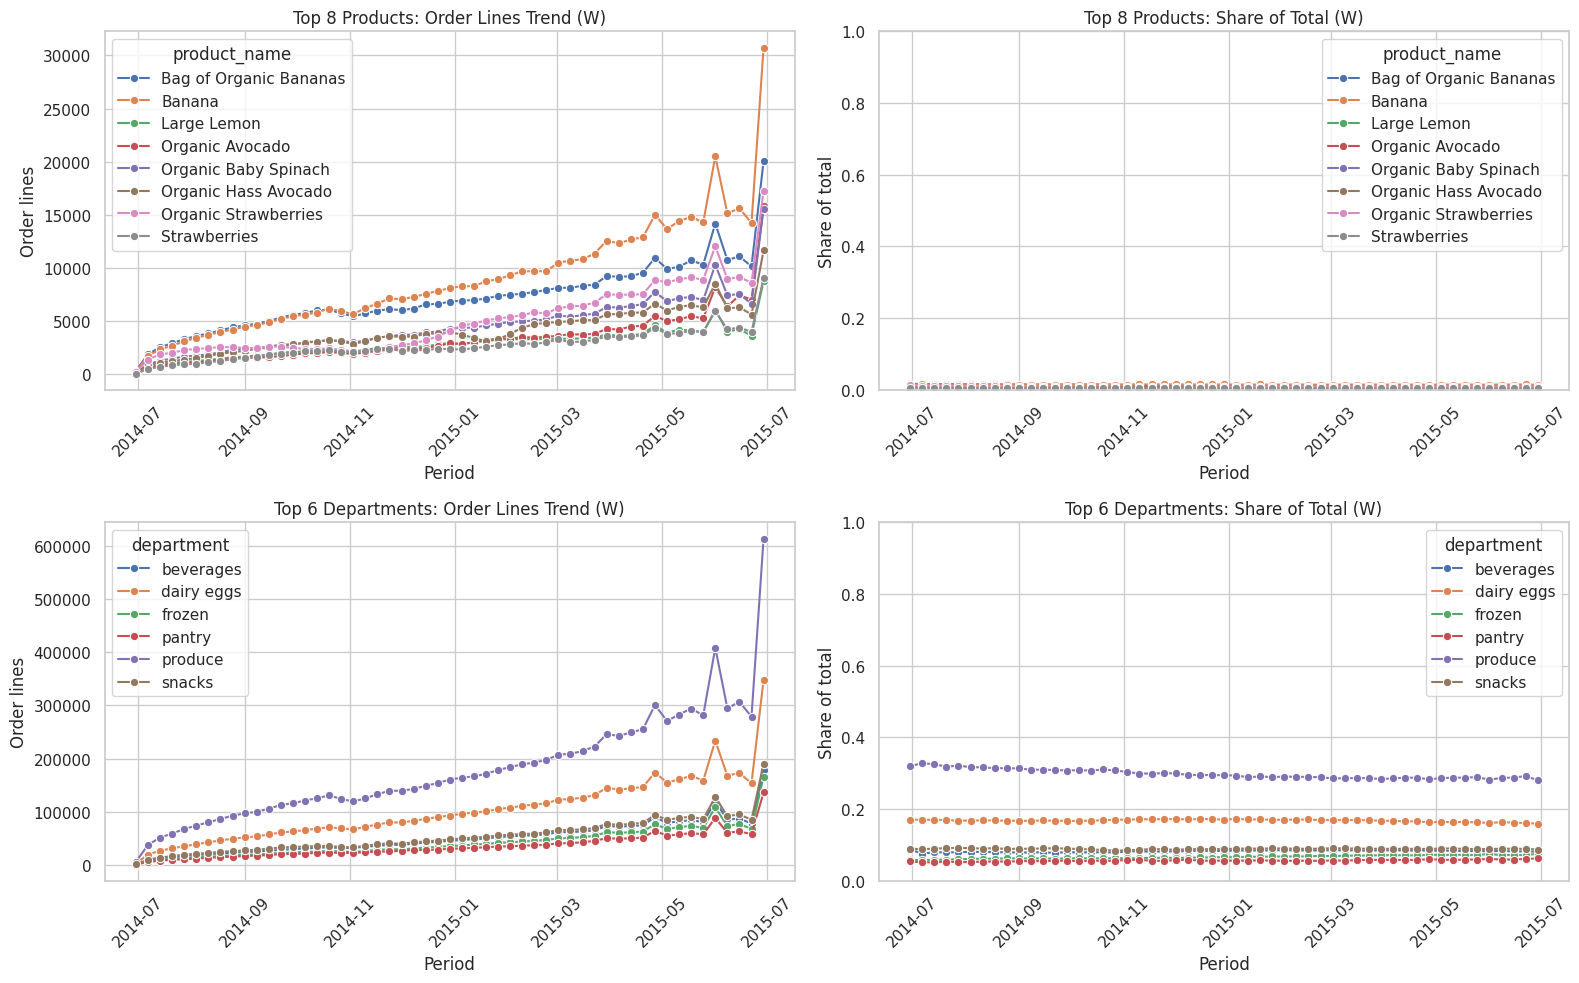

,period,product_name,order_lines,total_lines_period,share_of_total
0,2014-06-30,Bag of Organic Bananas,347,20541,0.0169
8,2014-07-07,Bag of Organic Bananas,1901,116219,0.0164
16,2014-07-14,Bag of Organic Bananas,2554,159468,0.0160
24,2014-07-21,Bag of Organic Bananas,2936,186121,0.0158
32,2014-07-28,Bag of Organic Bananas,3317,211681,0.0157
40,2014-08-04,Bag of Organic Bananas,3609,233989,0.0154
48,2014-08-11,Bag of Organic Bananas,3860,254191,0.0152
56,2014-08-18,Bag of Organic Bananas,4138,275798,0.0150
64,2014-08-25,Bag of Organic Bananas,4430,295816,0.0150
72,2014-09-01,Bag of Organic Bananas,4602,309658,0.0149


,period,department,order_lines,total_lines_period,share_of_total
0,2014-06-30,beverages,1792,20541,0.0872
6,2014-07-07,beverages,8860,116219,0.0762
12,2014-07-14,beverages,12687,159468,0.0796
18,2014-07-21,beverages,14773,186121,0.0794
24,2014-07-28,beverages,16879,211681,0.0797
30,2014-08-04,beverages,18859,233989,0.0806
36,2014-08-11,beverages,20498,254191,0.0806
42,2014-08-18,beverages,21986,275798,0.0797
48,2014-08-25,beverages,23581,295816,0.0797
54,2014-09-01,beverages,24351,309658,0.0786


In [ ]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(user_trend, title="User trend summary:")

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(product_period.sort_values(["product_name", "period"]), title="Product trend sample:")
show_df(dept_period.sort_values(["department", "period"]), title="Department trend sample:")

## 8) Distribution Diagnostics (Histogram Supplements)

ใช้ histogram เพื่ออ่าน shape ของการกระจาย (ไม่ใช่ time trend)
- `days_since_prior_order`
- `orders_per_user`
- `product_growth_rate` ข้ามช่วงเวลา

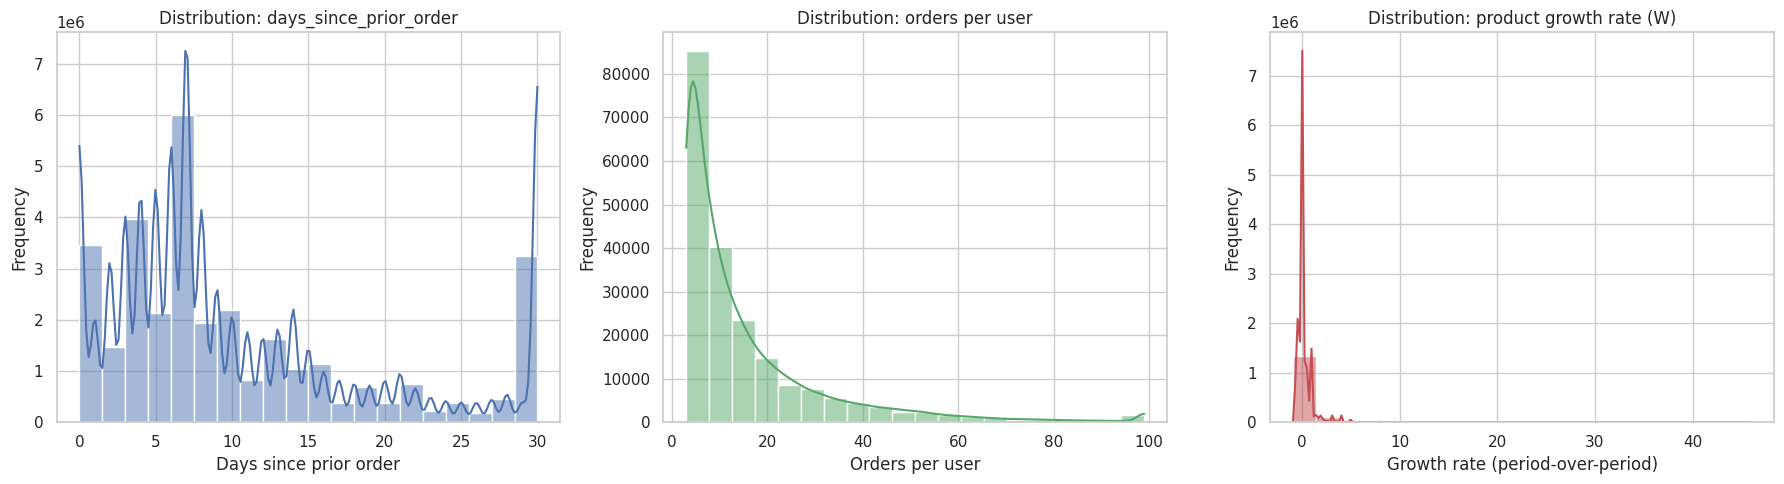

,orders_per_user
count,"206,209.0000"
mean,15.5904
std,16.6548
min,3.0000
25%,5.0000
50%,9.0000
75%,19.0000
max,99.0000


,product_growth_rate
count,"1,458,728.0000"
mean,0.2695
std,0.9383
min,-0.9375
25%,-0.2000
50%,0.0000
75%,0.5000
max,46.0000


In [ ]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

show_df(user_order_freq.describe().to_frame(name="orders_per_user"), title="orders_per_user summary:")
show_df(growth_values.describe().to_frame(name="product_growth_rate"), title="product_growth_rate summary:")

# --- Executive summary block (auto-refresh after re-run) ---
segment_snapshot = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
segment_snapshot["user_share"] = segment_snapshot["users"] / segment_snapshot["users"].sum()

print("\n=== Executive Summary (Quick Read) ===")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Orders: {df['order_id'].nunique():,}")
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")
show_df(segment_snapshot, title="Segment snapshot:")

top5 = df["product_name"].value_counts().head(5).rename("order_lines").to_frame()
show_df(top5, title="Top 5 products overall (order lines):")

print("Overall reorder rate:", f"{df['reordered'].mean():.2%}")
print("Median days_since_prior_order:", f"{df['days_since_prior_order'].median():.1f}")

## 9) Executive Summary (Interpretation Template)

ใช้ checklist นี้ตอนสรุปผลประชุม/พรีเซนต์

- Segment story: Whales / Regulars / Churned ต่างกันที่อะไร (order frequency, reorder, recency)
- Time-slot story: วันและชั่วโมงไหนมีทั้ง volume และ reorder สูง
- Category story: หมวดไหน repeat สูง และหมวดไหนมูลค่าตะกร้าสูง
- Risk story: threshold churn ที่เหมาะกับธุรกิจ และ segment ไหนเสี่ยงสุด
- Action story: แผนที่ควรทำทันที 3 อย่าง (retain Whales, grow Regulars, win-back Churned)

หมายเหตุ: ให้รัน cell summary ก่อนหน้าเพื่ออัปเดตตัวเลขล่าสุดทุกครั้ง